In [5]:
from astropy.io import fits
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

In [6]:
# # Función para graficar un espectro aleatorio
# def plot_random_spectrum(flux, wavelength, title=""):
#     idx = np.random.randint(0, flux.shape[0])
#     plt.figure(figsize=(8,4))
#     plt.plot(wavelength[idx], flux[idx])
#     plt.xlabel("Wavelength")
#     plt.ylabel("Flux")
#     plt.title(f"{title} - Spectrum index {idx}")
#     plt.show()

# # Función para cargar datos usando np.memmap y copiarlos a memoria
# def load_data(file_flux, file_wave, file_redshift, total, num_points):
#     flux = np.memmap(file_flux, dtype="float32", mode="r", shape=(total, num_points))
#     wavelength = np.memmap(file_wave, dtype="float32", mode="r", shape=(total, num_points))
#     redshift = np.memmap(file_redshift, dtype="float32", mode="r", shape=(total,))
#     return np.array(flux), np.array(wavelength), np.array(redshift)

# # Parámetros generales
# data_dir = "data"
# num_points = 5000
# big_total = 595472    # Número de espectros en bigtraining
# small_total = 4528    # Número de espectros en smalltraining

# # Rutas de archivos para bigtraining (archivos sin normalizar)
# big_flux_path     = os.path.join(data_dir, "spectra_data_bigtraining_flux.dat")
# big_wave_path     = os.path.join(data_dir, "spectra_data_bigtraining_wavelength.dat")
# big_redshift_path = os.path.join(data_dir, "spectra_data_bigtraining_redshift.dat")

# # Rutas de archivos para smalltraining
# small_flux_path     = os.path.join(data_dir, "spectra_data_smalltraining_flux.dat")
# small_wave_path     = os.path.join(data_dir, "spectra_data_smalltraining_wavelength.dat")
# small_redshift_path = os.path.join(data_dir, "spectra_data_smalltraining_redshift.dat")

# # Cargar datos
# print("Cargando datos de bigtraining...")
# flux_big, wavelength_big, redshift_big = load_data(big_flux_path, big_wave_path, big_redshift_path, big_total, num_points)
# print("Cargando datos de smalltraining...")
# flux_small, wavelength_small, redshift_small = load_data(small_flux_path, small_wave_path, small_redshift_path, small_total, num_points)

# # Mostrar un espectro aleatorio de cada dataset (Raw)
# plot_random_spectrum(flux_big, wavelength_big, "Bigtraining (Raw)")
# plot_random_spectrum(flux_small, wavelength_small, "Smalltraining (Raw)")

# # Dividir bigtraining en train (84%) y test (16%)
# indices_big = np.arange(big_total)
# big_train_indices, big_test_indices = train_test_split(indices_big, test_size=0.16, random_state=42)

# flux_big_train      = flux_big[big_train_indices]
# wavelength_big_train = wavelength_big[big_train_indices]
# redshift_big_train   = redshift_big[big_train_indices]

# flux_big_test       = flux_big[big_test_indices]
# wavelength_big_test  = wavelength_big[big_test_indices]
# redshift_big_test    = redshift_big[big_test_indices]

# plot_random_spectrum(flux_big_train, wavelength_big_train, "Bigtraining Train (Raw)")
# plot_random_spectrum(flux_big_test, wavelength_big_test, "Bigtraining Test (Raw)")

# # Crear el conjunto de entrenamiento final: bigtraining_train + smalltraining
# flux_train = np.concatenate([flux_big_train, flux_small], axis=0)
# wavelength_train = np.concatenate([wavelength_big_train, wavelength_small], axis=0)
# redshift_train = np.concatenate([redshift_big_train, redshift_small], axis=0)

# plot_random_spectrum(flux_train, wavelength_train, "Conjunto de Entrenamiento Final (Raw)")

# # Convertir a float32 para reducir uso de memoria
# flux_train = flux_train.astype(np.float32)
# wavelength_train = wavelength_train.astype(np.float32)
# flux_big_test = flux_big_test.astype(np.float32)
# wavelength_big_test = wavelength_big_test.astype(np.float32)

# # Definir variables para el escalado incremental
# chunk_size = 10000  # Puedes ajustar este valor según la memoria disponible
# num_samples = flux_train.shape[0]
# print(f"Total de muestras en entrenamiento: {num_samples}")

# # Ajuste incremental de StandardScaler para flux y wavelength
# flux_scaler = StandardScaler()
# wavelength_scaler = StandardScaler()
# print("Ajustando escaladores en chunks...")
# for start in range(0, num_samples, chunk_size):
#     end = min(start + chunk_size, num_samples)
#     flux_scaler.partial_fit(flux_train[start:end])
#     wavelength_scaler.partial_fit(wavelength_train[start:end])

# # Transformar el conjunto de entrenamiento en chunks usando np.memmap para evitar asignación masiva en RAM
# flux_train_scaled = np.memmap("flux_train_scaled.dat", dtype="float32", mode="w+", shape=flux_train.shape)
# wavelength_train_scaled = np.memmap("wavelength_train_scaled.dat", dtype="float32", mode="w+", shape=wavelength_train.shape)
# print("Transformando conjunto de entrenamiento en chunks...")
# for start in range(0, num_samples, chunk_size):
#     end = min(start + chunk_size, num_samples)
#     flux_train_scaled[start:end] = flux_scaler.transform(flux_train[start:end])
#     wavelength_train_scaled[start:end] = wavelength_scaler.transform(wavelength_train[start:end])

# # Transformar el conjunto de test en chunks usando np.memmap
# num_samples_test = flux_big_test.shape[0]
# flux_test_scaled = np.memmap("flux_test_scaled.dat", dtype="float32", mode="w+", shape=flux_big_test.shape)
# wavelength_test_scaled = np.memmap("wavelength_test_scaled.dat", dtype="float32", mode="w+", shape=wavelength_big_test.shape)
# print("Transformando conjunto de test en chunks...")
# for start in range(0, num_samples_test, chunk_size):
#     end = min(start + chunk_size, num_samples_test)
#     flux_test_scaled[start:end] = flux_scaler.transform(flux_big_test[start:end])
#     wavelength_test_scaled[start:end] = wavelength_scaler.transform(wavelength_big_test[start:end])

# # Mostrar un espectro aleatorio del conjunto de entrenamiento escalado
# plot_random_spectrum(flux_train_scaled, wavelength_train_scaled, "Conjunto de Entrenamiento Final (Scaled)")

# # Convertir a tensores de PyTorch (cargando el memmap en array)
# train_data = {
#     "flux": torch.tensor(np.array(flux_train_scaled), dtype=torch.float32),
#     "wavelength": torch.tensor(np.array(wavelength_train_scaled), dtype=torch.float32),
#     "redshift": torch.tensor(redshift_train, dtype=torch.float32)
# }
# test_data = {
#     "flux": torch.tensor(np.array(flux_test_scaled), dtype=torch.float32),
#     "wavelength": torch.tensor(np.array(wavelength_test_scaled), dtype=torch.float32),
#     "redshift": torch.tensor(redshift_big_test, dtype=torch.float32)
# }

# # Guardar los datasets preprocesados
# torch.save(train_data, os.path.join(data_dir, "train_dataset.pt"))
# torch.save(test_data, os.path.join(data_dir, "test_dataset.pt"))
# print("Datasets guardados exitosamente.")

# # Guardar los escaladores ajustados en un diccionario y luego en un archivo pickle
# scaler_dict = {
#     "flux_scaler": flux_scaler,
#     "wavelength_scaler": wavelength_scaler
# }
# scaler_filename = os.path.join(data_dir, "scaler_modelCNN_UPD_fitted.pkl")
# with open(scaler_filename, "wb") as f:
#     pickle.dump(scaler_dict, f)
# print(f"Scalers guardados en {scaler_filename}")

# # Se utiliza torch.from_numpy() para evitar copiar todo el contenido del memmap a un array completo.
# # Además, se añade unsqueeze(1) al tensor de redshift para que tenga forma [N, 1].

# train_data = {
#     "flux": torch.from_numpy(flux_train_scaled),
#     "wavelength": torch.from_numpy(wavelength_train_scaled),
#     "redshift": torch.from_numpy(redshift_train.astype(np.float32)).unsqueeze(1)
# }
# test_data = {
#     "flux": torch.from_numpy(flux_test_scaled),
#     "wavelength": torch.from_numpy(wavelength_test_scaled),
#     "redshift": torch.from_numpy(redshift_big_test.astype(np.float32)).unsqueeze(1)
# }

# torch.save(train_data, os.path.join(data_dir, "train_dataset.pt"))
# torch.save(test_data, os.path.join(data_dir, "test_dataset.pt"))
# print("Datasets (train y test) guardados exitosamente usando torch.from_numpy().")

# # Guardar los escaladores ajustados en un diccionario y luego en un archivo pickle
# scaler_dict = {
#     "flux_scaler": flux_scaler,
#     "wavelength_scaler": wavelength_scaler
# }
# scaler_filename = "extra/scaler_600k_fitted.pkl"
# with open(scaler_filename, "wb") as f:
#     pickle.dump(scaler_dict, f)
# print(f"Scalers guardados en {scaler_filename}")

In [7]:
# def plot_random_spectrum_from_dataset(dataset):
#     idx = random.randint(0, len(dataset) - 1)
#     input_sample, target = dataset[idx]
    
#     flux = input_sample[0].numpy()
#     wavelength = input_sample[1].numpy()
    
#     # Graficar el espectro
#     plt.figure(figsize=(20, 15))
#     plt.plot(wavelength, flux, label='Flux')
#     plt.xlabel('Wavelength')
#     plt.ylabel('Flux')
#     plt.title(f'Espectro aleatorio (índice {idx}) - Redshift: {target.item()}')
#     plt.legend()
#     plt.show()

# plot_random_spectrum_from_dataset(train_dataset)

# # Rutas de los datasets preprocesados
# data_dir = "data"
# train_dataset_path = os.path.join(data_dir, "train_dataset.pt")
# test_dataset_path  = os.path.join(data_dir, "test_dataset.pt")

# # Cargar los datasets
# train_data = torch.load(train_dataset_path)
# test_data = torch.load(test_dataset_path)

# # Extraer los redshifts
# redshifts_train = train_data["redshift"].numpy()
# redshifts_test = test_data["redshift"].numpy()

# # Definir bins para los rangos: 0-1, 1-2, ..., 7-8
# bins = np.arange(0, 9, 1)  # bins: [0, 1, 2, ..., 8]

# # Calcular histogramas
# train_hist, _ = np.histogram(redshifts_train, bins=bins)
# test_hist, _ = np.histogram(redshifts_test, bins=bins)

# # Imprimir los resultados para el conjunto de entrenamiento
# print("Distribución de redshifts en el conjunto de entrenamiento:")
# for i in range(len(train_hist)):
#     print(f"Rango {bins[i]} - {bins[i+1]}: {train_hist[i]}")

# # Imprimir los resultados para el conjunto de test
# print("\nDistribución de redshifts en el conjunto de test:")
# for i in range(len(test_hist)):
#     print(f"Rango {bins[i]} - {bins[i+1]}: {test_hist[i]}")

# Distribución de redshifts en el conjunto de entrenamiento:
# Rango 0 - 1: 427848
# Rango 1 - 2: 27893
# Rango 2 - 3: 32576
# Rango 3 - 4: 11750
# Rango 4 - 5: 2529
# Rango 5 - 6: 900
# Rango 6 - 7: 854
# Rango 7 - 8: 245

# Distribución de redshifts en el conjunto de test:
# Rango 0 - 1: 81553
# Rango 1 - 2: 5214
# Rango 2 - 3: 6168
# Rango 3 - 4: 2312
# Rango 4 - 5: 0
# Rango 5 - 6: 0
# Rango 6 - 7: 0
# Rango 7 - 8: 0

In [8]:
# import os
# import torch

# # Ruta del dataset procesado que ya tienes (por ejemplo, "train_dataset.pt")
# dataset_path = os.path.join("data", "test_dataset.pt")

# # Cargar el dataset previamente guardado
# data = torch.load(dataset_path)
# print("Shapes originales:")
# print("flux:", data["flux"].shape)
# print("wavelength:", data["wavelength"].shape)
# print("redshift:", data["redshift"].shape)

# # Ajustar la forma del redshift, añadiendo una dimensión para que tenga forma [N, 1]
# if len(data["redshift"].shape) == 1:
#     data["redshift"] = data["redshift"].unsqueeze(1)
# print("Shape de redshift ajustado:", data["redshift"].shape)

# # Guardar el dataset actualizado con un nuevo nombre
# new_dataset_path = os.path.join("data", "test_dataset_updated.pt")
# torch.save(data, new_dataset_path)
# print("Dataset actualizado guardado en:", new_dataset_path)

In [8]:
# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        # Cargamos el diccionario previamente guardado (.pt)
        data = torch.load(dataset_path)
        self.flux = data["flux"]          # Tensor con forma [N, num_points]
        self.wavelength = data["wavelength"]  # Tensor con forma [N, num_points]
        self.redshift = data["redshift"]      # Tensor con forma [N]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target

# Rutas a los archivos preprocesados
data_dir = "data"
train_dataset_path = os.path.join(data_dir, "train_dataset.pt")
test_dataset_path  = os.path.join(data_dir, "test_dataset.pt")

# Crear los datasets
train_dataset = SpectraDataset(train_dataset_path)
test_dataset  = SpectraDataset(test_dataset_path)

# Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [ ]:
# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Número de puntos en cada espectro
num_points = 5000

# Definir el modelo CNN en PyTorch con dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Tras 3 max pooling, la dimensión se reduce en un factor de 8
        conv_output_size = num_points // 8
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

modelCNN = CNN(num_points).to(device)
criterion = nn.L1Loss()
optimizer = optim.Adam(modelCNN.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

Usando dispositivo: cuda


In [ ]:
num_epochs = 1
for epoch in range(num_epochs):
    modelCNN.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelCNN(batch_X)
        # Asegurar que outputs tenga forma [batch_size] para comparar con batch_y
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)
    
    # Evaluación en el conjunto de validación
    modelCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)
    
    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}", flush=True)

# Evaluación final en el conjunto de prueba utilizando MAE
modelCNN.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_X.size(0)
test_loss /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_loss:.4f}")

# Guardar los parámetros del modelo
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': modelCNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'storage/modelCNN_UPD1_600ktest.pth')

Epoch 1/15, Loss: 0.3213, Val Loss: 310112.2955, LR: 0.0001000000
Epoch 2/15, Loss: 0.2577, Val Loss: 3833813.8030, LR: 0.0001000000
Epoch 3/15, Loss: 0.2327, Val Loss: 3264121.9279, LR: 0.0001000000
Epoch 4/15, Loss: 0.2158, Val Loss: 1741778.2235, LR: 0.0001000000
Epoch 5/15, Loss: 0.1993, Val Loss: 2964366.0332, LR: 0.0001000000
Epoch 6/15, Loss: 0.1888, Val Loss: 1133475.4324, LR: 0.0001000000
Epoch 7/15, Loss: 0.1819, Val Loss: 7997304.3126, LR: 0.0001000000
Epoch 8/15, Loss: 0.1734, Val Loss: 9958847.2247, LR: 0.0001000000
Epoch 9/15, Loss: 0.1696, Val Loss: 13769291.4119, LR: 0.0001000000
Epoch 10/15, Loss: 0.1644, Val Loss: 14717993.7324, LR: 0.0001000000
Epoch 11/15, Loss: 0.1623, Val Loss: 10017382.9269, LR: 0.0001000000
Epoch 12/15, Loss: 0.1571, Val Loss: 3548629.3945, LR: 0.0000500000
Epoch 13/15, Loss: 0.1438, Val Loss: 7497455.0641, LR: 0.0000500000
Epoch 14/15, Loss: 0.1405, Val Loss: 10385911.1348, LR: 0.0000500000
Epoch 15/15, Loss: 0.1383, Val Loss: 7578582.6541, LR:

In [ ]:
# Cargar checkpoint y estados del modelo, optimizador y scheduler
checkpoint = torch.load('storage/modelCNN_UPD1_600ktest.pth', map_location=device)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch']

# Definir el número total de epochs que deseas entrenar
num_epochs = 5

# Continuar el entrenamiento desde el epoch donde se quedó
for epoch in range(start_epoch, num_epochs):
    modelCNN.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)
    
    # Evaluación en el conjunto de validación
    modelCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)
    
    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}", flush=True)

# Evaluación final en el conjunto de prueba utilizando MAE
modelCNN.eval()
test_mae = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        test_mae += loss.item() * batch_X.size(0)
test_mae /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_mae:.4f}")

# Guardar los parámetros del modelo y el scaler
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': modelCNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'storage/modelCNN_UPD1_600ktest.pth')

Epoch 16/20, Loss: 0.1349, Val Loss: 16422270.8938, LR: 0.0000500000
Epoch 17/20, Loss: 0.1339, Val Loss: 8679765.7524, LR: 0.0000500000
Epoch 18/20, Loss: 0.1322, Val Loss: 4104214.7540, LR: 0.0000500000
Epoch 19/20, Loss: 0.1316, Val Loss: 6696999.7749, LR: 0.0000500000
Epoch 20/20, Loss: 0.1294, Val Loss: 9981595.9180, LR: 0.0000500000
Error absoluto medio en el conjunto de prueba: 10.3504


[0.47558007]
Redshift real: [0.47558007]
Redshift predicho: 0.4694523513317108


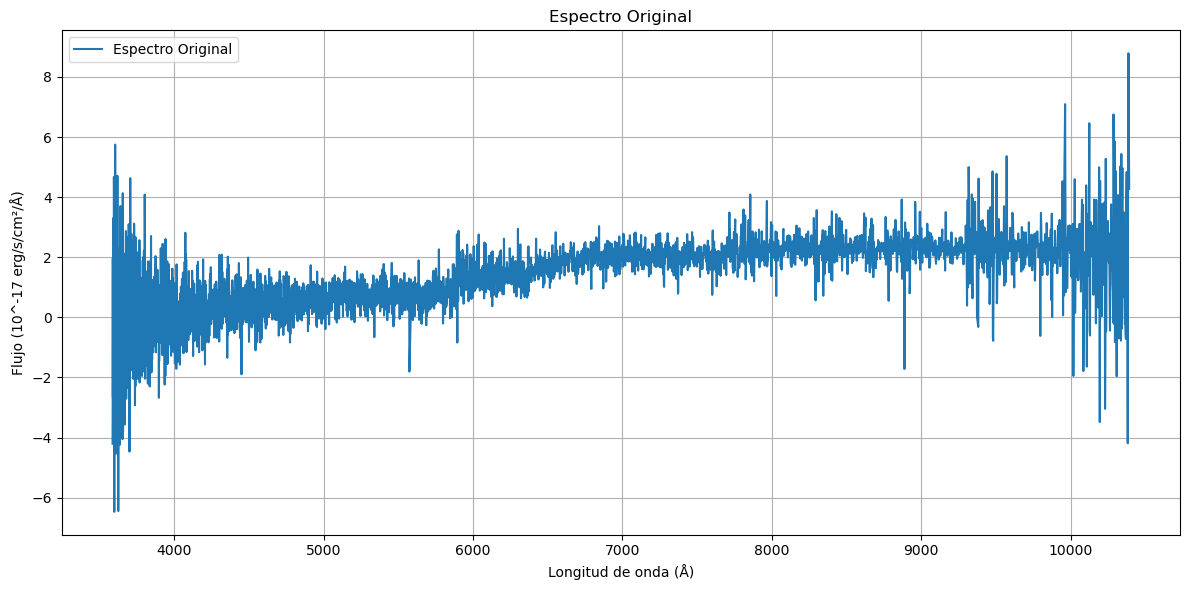

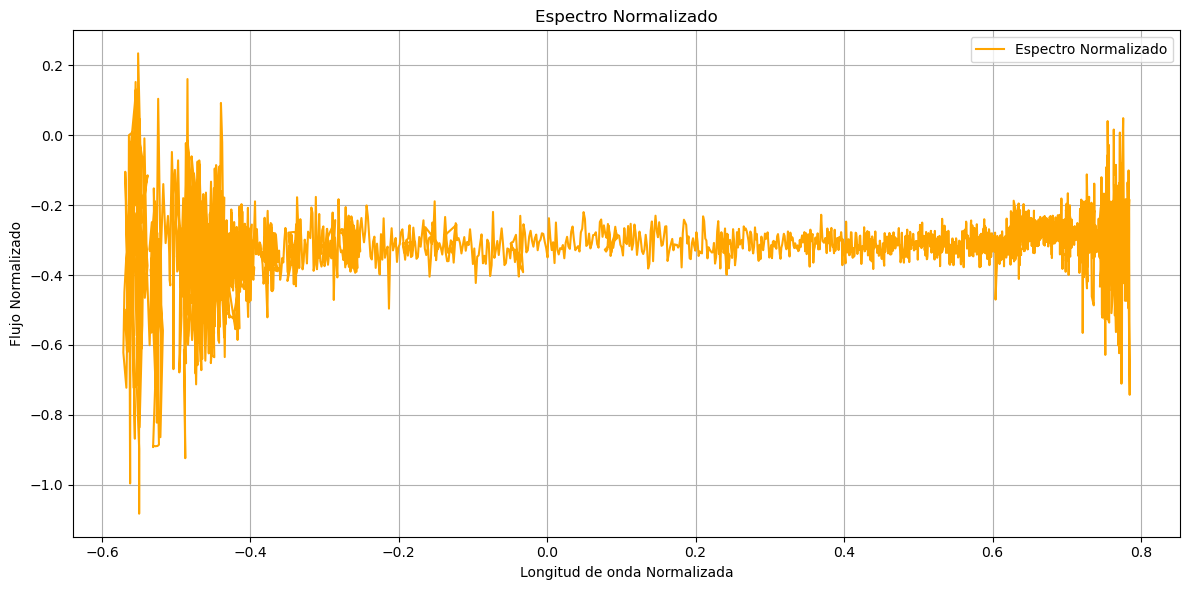

In [ ]:
# Obtener la lista inicial de archivos FITS
folder_path = r'spectrums'
files = [f for f in os.listdir(folder_path) if f.endswith('.fits')]
files = random.sample(files, len(files))
file_path = os.path.join(folder_path, files[0])

# Cargar el checkpoint del modelo y los escaladores
checkpoint = torch.load('storage/modelCNN_UPD1_600ktest.pth', map_location=device)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
modelCNN.eval()

# Los escaladores se encuentran en un diccionario con las claves "flux_scaler" y "wavelength_scaler"
with open('extra/scaler_600k_fitted.pkl', 'rb') as f:
    scaler_dict = pickle.load(f)
flux_scaler = scaler_dict["flux_scaler"]
wavelength_scaler = scaler_dict["wavelength_scaler"]

# Abrir el archivo FITS y extraer datos
with fits.open(file_path) as hdul:
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]
    test_redshift = hdul[2].data["Z"][0]

# Convertir loglam a wavelength
test_wavelength = 10 ** test_loglam

def expand_points(wavelength, flux, target_count=5000):
    # Convertir a listas para facilitar las inserciones
    wl = list(wavelength)
    fl = list(flux)
    
    # Calcular las diferencias absolutas entre puntos consecutivos
    diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl)-1)]
    # Obtener los índices ordenados de mayor a menor diferencia
    sorted_indices = sorted(range(len(diffs)), key=lambda i: diffs[i], reverse=True)
    
    # Insertar nuevos puntos utilizando los índices ordenados
    while len(wl) < target_count:
        # Se recorre la lista de índices en orden descendente para evitar problemas con el reordenamiento
        for idx in sorted_indices:
            if len(wl) >= target_count:
                break
            # Calcular la interpolación lineal entre el punto idx y el siguiente
            new_wl = (wl[idx] + wl[idx+1]) / 2
            new_fl = (fl[idx] + fl[idx+1]) / 2
            # Insertar el nuevo punto en la posición correspondiente
            wl.insert(idx+1, new_wl)
            fl.insert(idx+1, new_fl)
    
    return np.array(wl), np.array(fl)

# Asegurarse de tener exactamente num_points
test_wavelength, test_flux = expand_points(test_wavelength, test_flux, target_count=num_points)

# Preprocesamiento para el modelo
# El modelo espera dos canales: canal 0 -> flux y canal 1 -> wavelength.
# Separamos cada canal y aplicamos el escalador correspondiente.
# Cada escalador fue ajustado en datos de forma (n_samples, 5000)

# Redimensionar cada canal para que tenga forma (1, num_points)
input_flux = test_flux.reshape(1, -1)              # (1, 5000)
input_wavelength = test_wavelength.reshape(1, -1)  # (1, 5000)

# Aplicar la normalización con los escaladores correspondientes
flux_scaled = flux_scaler.transform(input_flux)                     # (1, 5000)
wavelength_scaled = wavelength_scaler.transform(input_wavelength)   # (1, 5000)

# Reconstruir el input con dos canales: (2, 5000) y agregar dimensión de batch => (1, 2, 5000)
input_scaled = np.stack([flux_scaled[0], wavelength_scaled[0]], axis=0)
input_scaled = input_scaled.reshape(1, 2, num_points)

# Convertir a tensor (usando torch.from_numpy para no saturar la memoria)
input_tensor = torch.from_numpy(input_scaled).to(device)

# Evaluación del modelo
with torch.no_grad():
    predicted_redshift = modelCNN(input_tensor)

print("Redshift real:", test_redshift)
print("Redshift predicho:", predicted_redshift.item())

# Representación de espectros
plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Espectro Original")
plt.xlabel("Longitud de onda (Å)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro Original")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(wavelength_scaled.flatten(), flux_scaled.flatten(), label="Espectro Normalizado", color="orange")
plt.xlabel("Longitud de onda Normalizada")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro Normalizado")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.colors as colors

















class SpectraMemmapDataset(Dataset):
    """
    Carga y normaliza espectros usando dos escaladores: uno para flux y otro para wavelength.
    """
    def __init__(self, flux_file, wavelength_file, redshift_file, total_spectra, num_points, scaler_path):
        self.flux = np.memmap(flux_file, dtype='float32', mode='r', shape=(total_spectra, num_points))
        self.wavelength = np.memmap(wavelength_file, dtype='float32', mode='r', shape=(total_spectra, num_points))
        self.redshift = np.memmap(redshift_file, dtype='float32', mode='r', shape=(total_spectra,))
        self.total_spectra = total_spectra
        self.num_points = num_points
        
        # Cargar el diccionario de escaladores preajustados
        with open(scaler_path, 'rb') as f:
            scaler_dict = pickle.load(f)
        self.flux_scaler = scaler_dict["flux_scaler"]
        self.wavelength_scaler = scaler_dict["wavelength_scaler"]
    
    def __len__(self):
        return self.total_spectra
    
    def __getitem__(self, idx):
        # Extraer los datos para el espectro idx
        flux = self.flux[idx]              # shape: (num_points,)
        wavelength = self.wavelength[idx]  # shape: (num_points,)
        redshift = self.redshift[idx]
        
        # Redimensionar cada canal a (1, num_points) para aplicar el escalado
        flux_reshaped = flux.reshape(1, -1)              # (1, num_points)
        wavelength_reshaped = wavelength.reshape(1, -1)  # (1, num_points)

        # Aplicar los escaladores por separado
        flux_scaled = self.flux_scaler.transform(flux_reshaped)                    # (1, num_points)
        wavelength_scaled = self.wavelength_scaler.transform(wavelength_reshaped)  # (1, num_points)

        # Combinar en un array de forma (2, num_points)
        x_scaled = np.stack([flux_scaled[0], wavelength_scaled[0]], axis=0)        # (2, num_points)

        # Convertir a tensores
        x_tensor = torch.tensor(x_scaled, dtype=torch.float32)
        y_tensor = torch.tensor(redshift, dtype=torch.float32)
        return x_tensor, y_tensor

# Parámetros
total_spectra = 3372890
num_points = 5000

# Rutas de archivos
flux_file =        'data/spectra_data_complete_flux.dat'
wavelength_file =  'data/spectra_data_complete_wavelength.dat'
redshift_file =    'data/spectra_data_complete_redshift.dat'
scaler_path =      'extra/scaler_600k_fitted.pkl'
model_checkpoint = 'storage/modelCNN_UPD1_600ktest.pth'

# Crear el dataset y el DataLoader
dataset = SpectraMemmapDataset(flux_file, wavelength_file, redshift_file,
                               total_spectra, num_points, scaler_path)
dataloader = DataLoader(dataset, batch_size=20000, shuffle=False)

# Instanciar el modelo y cargar el checkpoint
modelCNN = CNN(num_points).to(device)
checkpoint = torch.load(model_checkpoint, map_location=device)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
modelCNN.eval()

# Evaluación del modelo utilizando el DataLoader
all_preds = []
all_y = []

with torch.no_grad():
    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        preds = modelCNN(x_batch).cpu().numpy()  # shape: (batch_size, 1)
        all_preds.append(preds)
        all_y.append(y_batch.numpy())

ypredicted = np.concatenate(all_preds, axis=0)  # (total_spectra, 1)
yreal = np.concatenate(all_y, axis=0)           # (total_spectra,)

# Calcular la correlación lineal
ypred_squeezed = ypredicted.squeeze()           # pasar de (N,1) a (N,)
lincorr = np.corrcoef(yreal, ypred_squeezed)[0, 1]
print(f"Correlación lineal: {lincorr:.4f}")
print(f"Número de muestras: {len(yreal)}")

In [ ]:
# Dispersión de puntos de z_real frente a z_predicho

plt.rcdefaults()
plt.figure(figsize=(10, 8))
plt.scatter(yreal, ypredicted, alpha=0.6, label='Datos')
plt.xlabel('Redshift Real')
plt.ylabel('Redshift Predicho')
plt.title('Comparación entre Redshift Real y Predicho')
# Añadir la línea ideal (y=x)
min_val = min(yreal.min(), ypredicted.min())
max_val = max(yreal.max(), ypredicted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
plt.legend()
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.show()






# Mapa de calor de z_real frente a z_predicho éstandar

plt.style.use('dark_background')

x_min, x_max = 0, 8
y_min, y_max = 0, 8

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted[:, 0],      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar negatividad

plt.style.use('dark_background')

x_min, x_max = -1, 8
y_min, y_max = -1, 0

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted[:, 0],      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar rangos bajos

plt.style.use('dark_background')

x_min, x_max = 0, 1
y_min, y_max = 0, 1

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted[:, 0],      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar rangos intermedios

plt.style.use('dark_background')

x_min, x_max = 1, 5
y_min, y_max = 1, 5

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted[:, 0],      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()







# Mapa de calor de z_real frente a z_predicho para comprobar rangos altos

plt.style.use('dark_background')

x_min, x_max = 5, 8
y_min, y_max = 1, 8

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted[:, 0],      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()